# Does the Treasury's "QRA" really shake the bond market? 🏛️
### The Quarterly Refunding Announcement — 2023's scariest new acronym, measured against 26 years of tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![2023_regime_change%3F: Busted](https://img.shields.io/badge/2023_regime_change%3F-Busted-8b949e?style=flat-square)

In the autumn of 2023 a sleepy bureaucratic ritual became macro folklore. Four times a year the U.S. Treasury announces **how much debt it plans to sell** — the *Quarterly Refunding Announcement*. In August 2023 it announced more than expected and long-term yields ripped higher; in November it announced less and they collapsed. Overnight, "QRA day" joined Fed day and CPI day on every macro calendar.

So we did the boring thing: we collected **every QRA since 2000 — all 106 of them** — and measured what the 10-year Treasury yield actually does on announcement day.

> 📓 **Plain-language layer.** Want the Welch *t*s, the placebo and the decontamination details? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **One trap up front.** QRA day is a Wednesday in early February, May, August and November. Guess who else loves those exact Wednesdays? **The Fed.** 35% of all QRA days are *also* FOMC statement days (including the famous 2023-11-01!). Every honest number below strips those out. House style: [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from quarterly_refunding_shock import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TNX, TYX, TLT = data.load_real()
    DY = st.dy_bps(TNX)
    LIDX = pd.DatetimeIndex(TNX.index)
    SP = st.clean_split(LIDX, data.QRA_DATES, data.FOMC_DATES)
    CLEAN = st.align_positions(LIDX, DY.index, SP["clean_pos"])
    ALLQ = st.align_positions(LIDX, DY.index, SP["qra_pos"])
    BASE = SP["base_mask"][1:]
else:
    TNX = TYX = TLT = DY = None
print("real cache present:", HAVE_REAL, "| QRA dates:", len(data.QRA_DATES))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_qra': 106, 'first': '2000-02-02', 'last': '2026-05-06', 'n_clean': 69, 'n_overlap': 37, 'overlap_pct': 35, 'n_base': 5936, 'day0_clean': (69, 3.86, 4.28, 0.9, -1.12, 0.03, 0.05), 'day0_all': (106, 3.91, 4.28, 0.91, -1.18, -0.3, -0.61), 'day0_overlap': (37, 4.02, 4.28, 0.94, -0.48, -0.91, -1.08), 'fomc_only': (175, 5.17, 1.21, 2.24), 'placebo_p': 0.823, 'placebo_draw_mean': 4.27, 'y30': (4.37, 3.97, 1.1, 0.73, 0.1, 0.13), 'window': [(-1, 4.67, 0.91, -0.25, -0.35), (0, 3.86, -1.12, 0.03, 0.05), (1, 3.99, -0.69, -0.77, -1.23), (2, 6.42, 4.1, 2.17, 2.41), (3, 3.49, -1.72, 0.48, 0.77)], 'jobs': {'n_day2': 69, 'n_ff': 63, 'share_pct': 91, 'abs_all': 6.42, 'welch_all': 4.1, 'abs_ff': 6.62, 'abs_ex': 4.3, 'welch_ex': 0.01, 'n_ex': 6}, 'era_all': {'early': 0.9, 'n_early': 92, 'late': 1.17, 'n_late': 14, 'welch': 1.21, 'trim': 1.2, 'n_trim': 12, 'welch_trim': 1.16}, 'era_clean': {'early': 0.95, 'n_early': 62, 'late': 0.99, 'n_late': 7, 'welch': 0.1, 'trim': 1.07, 'n_trim': 6, 'welch_trim': 0.26}, 'episodes': [('2023-07-31', 'borrowing estimate (+$274B surprise)', -1.0), ('2023-08-02', 'QRA statement (sizes up; Fitch downgrade eve)', 2.7), ('2023-10-30', 'borrowing estimate ($76B below flag)', 3.0), ('2023-11-01', 'QRA statement (slower; same-day FOMC)', -8.6)], 'week_aug': 9.1, 'week_nov': -28.7, 'tlt': {'n': 96, 'uncond': -14.3, 'uncond_t': -0.89, 'base': 4.6, 'welch': -1.15, 'cond': -21.3, 'cond_t': -1.33, 'net': [(2.0, -18.3, -73, -25.3, -102), (5.0, -24.3, -97, -31.3, -126)]}, 'syn': [(1.0, 0.0, 1.08, 1.09, -0.91, -1.48), (2.0, 0.0, 2.17, 7.65, -1.81, -1.48), (1.0, 4.0, 1.19, 2.2, 3.09, 5.05)], 'fp_tnx': '07c63093f8d2', 'fp_tyx': '0f37876ddb3a', 'fp_tlt': 'ef0fdae90551'}


real cache present: True | QRA dates: 106


## The answer first

| Question | Answer |
|---|---|
| Does the bond market jump on QRA day? | **No.** On the 69 clean QRA days (no Fed the same day) the 10-year moves **slightly LESS** than on an ordinary day — 3.9 bps vs 4.3 bps. A random set of days beats the QRA calendar 82% of the time. |
| But… August and November 2023?! | Those were loud **weeks**, not loud announcements. Aug 2, 2023 itself moved **+2.7 bps** (half an ordinary day!) — the week's damage came with a US credit downgrade and a jobs report attached. Nov 1's drop had an **FOMC meeting the same afternoon**. |
| Is there money in trading it? | **No.** Buying TLT at the QRA close and holding 3 days *lost* money on average over 96 events — before costs. |
| Could your method just be blind? | **No.** The same method, on the same tape, lights up on FOMC days (×1.21 an ordinary day, statistically solid) and on planted synthetic shocks. It sees real events fine — there's just nothing here. |

> The QRA is genuinely important **policy**. It just isn't an announcement-day **shock** — by the time Treasury speaks at 8:30, the market has mostly guessed the answer.

## 1 · The claim

> *"Treasury supply now drives the long end. The Quarterly Refunding Announcement moves 10- and 30-year yields the way Fed meetings do — August and November 2023 proved it."*

That's the strong, testable version of what macro Twitter, a famous 2024 paper on "activist Treasury issuance", and a thousand desk notes started saying after 2023. The mechanics: on the Monday Treasury reveals **how much** it needs to borrow; on the Wednesday at 8:30am it reveals **which maturities** will carry the load. Surprise supply at the long end should mean higher long yields — *if* it's a surprise.

The word doing all the work is **surprise**. Auction sizes are guessed in advance by a whole industry (Treasury even surveys the dealers first). Our question is narrow and clean: **on the day itself, does the long end actually move more than usual?**

## 2 · So what?

If QRA day is a genuine macro event you should: hedge into it, expect option markets to price it, and maybe trade the reaction. If it *isn't* — if the 2023 story is survivor-bias on two loud weeks — then "QRA risk" is a cost you're paying for a ghost. Getting this right is worth real money to anyone who trades bonds around the refunding calendar.

It's also a beautiful case study in **how folklore is born**: two big weeks + a plausible mechanism + a calendar collision with the Fed and the jobs report = a "new macro event" that nobody re-measured.

## 3 · How would we even know?

- **Every QRA since 2000.** We rebuilt the calendar — **106 announcement dates** — from the official TreasuryDirect auction records (the refunding securities are announced *via* the QRA statement, so their official announcement date IS the QRA date). All 106 are Wednesdays, 8:30am ET.
- **The Fed decontamination.** 37 of the 106 (35%) are *also* FOMC statement days — same early-quarter Wednesdays. Daily data can't split an 8:30am statement from a 2pm one, so the headline test uses only the **69 Fed-free QRA days**.
- **The measure.** The 10-year yield's move on QRA day vs ordinary days (with a random-calendar placebo), the surrounding days (−1 to +3), the 30-year as a check, and a simple TLT trade for the money question.

## 4 · The teardown — let's actually look

**The headline picture.** Average size of the 10-year yield's daily move: ordinary days, clean QRA days, and — for contrast — actual FOMC days on the same tape.

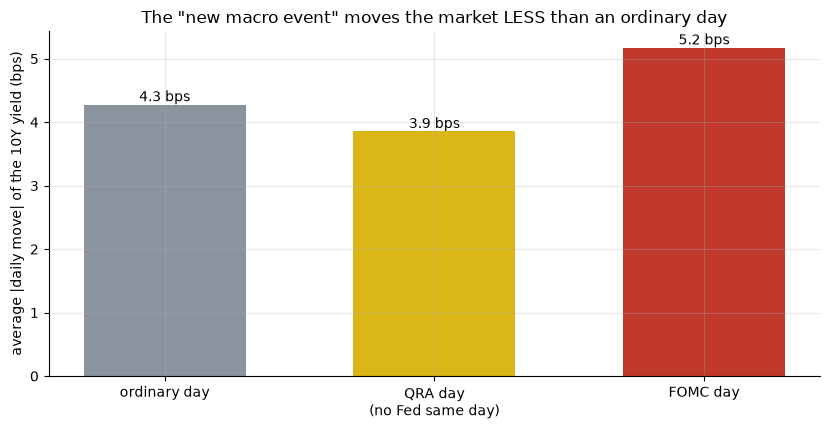

ordinary 4.28 bps | QRA 3.86 bps | FOMC 5.17 bps


In [2]:
if HAVE_REAL:
    s_c = st.day0_stats(DY, CLEAN, BASE)
    qset = set(SP['qra_pos'])
    fpos = [p for p in st.event_positions(LIDX, data.FOMC_DATES) if p not in qset]
    s_f = st.day0_stats(DY, st.align_positions(LIDX, DY.index, fpos), BASE)
    vals = [s_c['abs_base'], s_c['abs_event'], s_f['abs_event']]
else:
    vals = [R['day0_clean'][2], R['day0_clean'][1], R['fomc_only'][1]]
labs = ['ordinary day', 'QRA day\n(no Fed same day)', 'FOMC day']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(labs, vals, color=[GREY, AMBER, RED], width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:.1f} bps', (i, v), ha='center', va='bottom')
ax.set_ylabel('average |daily move| of the 10Y yield (bps)')
ax.set_title('The "new macro event" moves the market LESS than an ordinary day')
plt.tight_layout(); plt.show()
print(f'ordinary {vals[0]:.2f} bps | QRA {vals[1]:.2f} bps | FOMC {vals[2]:.2f} bps')

There's the whole study in one chart. Clean QRA days average **3.9 bps** of movement vs **4.3 bps** on an ordinary day — QRA day is *quieter* than average. FOMC days, measured the exact same way on the exact same tape, average **5.2 bps** (×1.21, statistically solid). The method sees real events. It just doesn't see this one.

**But what about 2023?** Let's zoom into the two famous episodes.

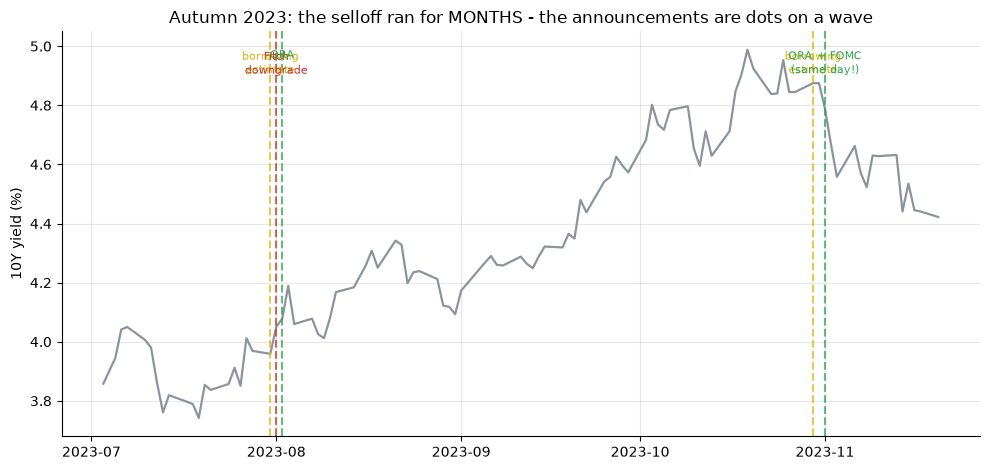

Aug 2 QRA day itself: +2.7 bps ; Nov 1 QRA(+FOMC) day: -8.6 bps


In [3]:
if HAVE_REAL:
    w = TNX.loc['2023-07-01':'2023-11-20']
    fig, ax = plt.subplots(figsize=(10.0, 4.8))
    ax.plot(w.index, w.values, color=GREY, lw=1.6)
    marks = [('2023-07-31', 'borrowing\nestimate', AMBER), ('2023-08-01', 'Fitch\ndowngrade', RED),
             ('2023-08-02', 'QRA', GREEN), ('2023-10-30', 'borrowing\nestimate', AMBER),
             ('2023-11-01', 'QRA + FOMC\n(same day!)', GREEN)]
    for d, lab, c in marks:
        ts = pd.Timestamp(d)
        if ts in w.index:
            ax.axvline(ts, color=c, ls='--', alpha=.75)
            ax.annotate(lab, (ts, w.max()), ha='center', va='top', fontsize=8, color=c)
    ax.set_ylabel('10Y yield (%)')
    ax.set_title('Autumn 2023: the selloff ran for MONTHS - the announcements are dots on a wave')
    plt.tight_layout(); plt.show()
    print('Aug 2 QRA day itself:', f"{DY.loc[pd.Timestamp('2023-08-02')]:+.1f} bps ;",
          'Nov 1 QRA(+FOMC) day:', f"{DY.loc[pd.Timestamp('2023-11-01')]:+.1f} bps")
else:
    eps = R['episodes']
    fig, ax = plt.subplots(figsize=(9.0, 4.4))
    ax.bar([e[0] for e in eps], [e[2] for e in eps], color=[AMBER, GREEN, AMBER, GREEN], width=.55)
    ax.set_ylabel('day-0 move of the 10Y (bps)'); ax.axhline(0, color=GREY)
    ax.set_title('The four famous 2023 days: small moves, big confounds')
    plt.tight_layout(); plt.show()
    for d, lab, v in eps: print(f'{d}: {v:+.1f} bps - {lab}')

Now the anticlimax, in numbers:

- **July 31, 2023** — the +$274B borrowing shock that starts the legend: the 10Y moved **-1.0 bps** that day. Yes, *minus* one.
- **Aug 2, 2023** — QRA day itself: **+2.7 bps**, about *half* an ordinary day's move. The week's +9 bps came with **Fitch stripping the US AAA** the evening before and a jobs report two days later.
- **Nov 1, 2023** — the famous rally, **-8.6 bps**… with an **FOMC statement the same afternoon**. On daily data the QRA can't even claim that move as its own; the refunding *week* fell 29 bps with the Fed, the QRA and the jobs report all inside it.

**One more trap — the "aftershock" that isn't.** Look two days after the QRA and the market *does* jump. Why? QRA is an early-month Wednesday… and **two days after an early-month Wednesday is the first Friday: jobs day.**

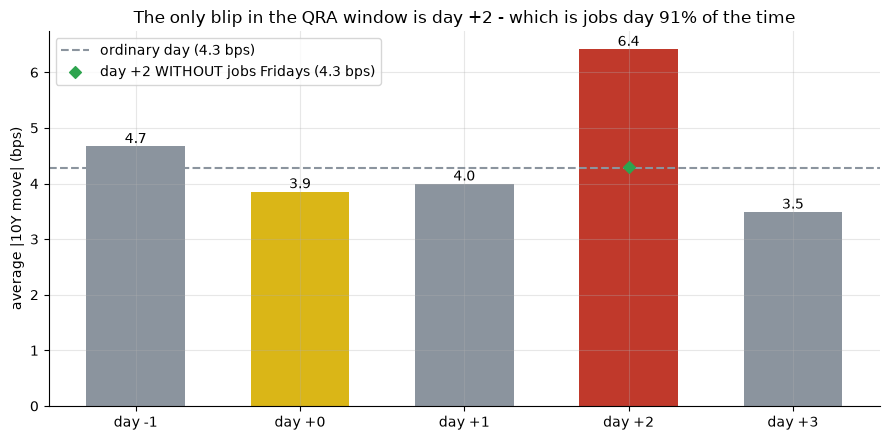

day +2 with jobs Fridays: 6.4 bps | without: 4.3 bps | share of jobs Fridays: 91%


In [4]:
if HAVE_REAL:
    prof = st.window_profile(DY, CLEAN, BASE)
    offs = [p['offset'] for p in prof]; vals = [p['abs_mean'] for p in prof]
    base = prof[0]['abs_base']
    dj = st.day2_jobs_diagnostic(DY, CLEAN, BASE)
    exff, share = dj['abs_ex_ff'], dj['share_first_friday']*100
else:
    offs = [w[0] for w in R['window']]; vals = [w[1] for w in R['window']]
    base = R['day0_clean'][2]; exff = R['jobs']['abs_ex']; share = R['jobs']['share_pct']
fig, ax = plt.subplots(figsize=(9.0, 4.5))
cols = [AMBER if o == 0 else (RED if o == 2 else GREY) for o in offs]
ax.bar([f'day {o:+d}' for o in offs], vals, color=cols, width=.6)
ax.axhline(base, ls='--', c=GREY, label=f'ordinary day ({base:.1f} bps)')
ax.scatter(['day +2'], [exff], marker='D', color=GREEN, zorder=5,
           label=f'day +2 WITHOUT jobs Fridays ({exff:.1f} bps)')
for i, v in enumerate(vals): ax.annotate(f'{v:.1f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('average |10Y move| (bps)')
ax.set_title(f'The only blip in the QRA window is day +2 - which is jobs day {share:.0f}% of the time')
ax.legend(); plt.tight_layout(); plt.show()
print(f'day +2 with jobs Fridays: {vals[3]:.1f} bps | without: {exff:.1f} bps | share of jobs Fridays: {share:.0f}%')

**91%** of the day+2 sessions are first-Friday jobs reports. Remove them and day+2 falls from **6.4** to **4.3 bps** — indistinguishable from an ordinary day. The whole QRA window contains exactly one real event, and it belongs to the Bureau of Labor Statistics.

## 5 · The verdict

- **Signal — None.** Across 106 announcements, clean QRA days move **3.9 bps vs 4.3** on ordinary days — *less*, not more. Random calendars beat the QRA calendar 82% of the time. The 30-year says the same. 
- **Tradability — Mirage.** TLT bought at the QRA close and held 3 days: **-14 bps per event before costs** over 96 events. There is nothing to monetise.
- **"2023 changed the game"? — Busted.** Judged against 2023's own (high) noise level, Fed-free QRA days since 2023 are exactly as ordinary as they were in 2000–2022. The two famous days were small on the day and entangled with Fitch, the FOMC and the jobs report.

## 6 · Going further 🚪

- **The supply story isn't dead — it lives at the auctions.** Desk sibling [603-treasury-auction-concession](../../603-treasury-auction-concession/README.md) finds yields genuinely back up 1.5–3 bps into the 10Y/30Y **auctions** (the days the bonds actually hit the tape). Supply matters where it's *absorbed*, not where it's *announced*.
- **Why so quiet?** Treasury surveys the primary dealers before every refunding and publishes guidance; by 8:30am Wednesday the sizes are mostly a formality. "Priced in" is not a slogan here — it's measurable.
- **Build your own.** Swap in intraday data around 8:30am, or the Monday borrowing-estimate releases, or 10s30s curve moves — the harness takes any date list.

*Think the QRA still matters? Show us a clean announcement-day move that survives the Fed and the jobs report — the event table is hardcoded and waiting.*